# PART 1

Using device: GPU
Loading dataset...


/tmp/ipykernel_47/3517445864.py:24: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(



Created balanced dataset of 1000 rows.
label
1    500
0    500
Name: count, dtype: int64

Loading Zero-Shot Model...


Device set to use cuda:0



Running Zero-Shot Inference on 1000 samples...


Processing Batches: 100%|██████████| 63/63 [00:58<00:00,  1.07it/s]


ZERO-SHOT MODEL PERFORMANCE
Accuracy: 0.4980

Classification Report:

              precision    recall  f1-score   support

  legitimate       0.50      0.84      0.63       500
    phishing       0.49      0.15      0.23       500

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.43      1000
weighted avg       0.50      0.50      0.43      1000



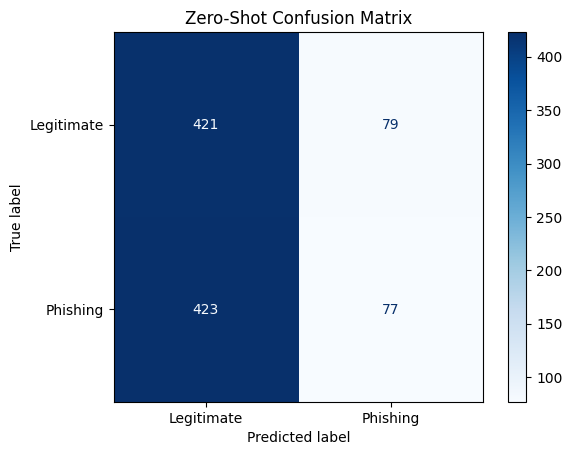

In [9]:
# ---------------------------
# 0) IMPORTS & SETUP
# ---------------------------
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Check device
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# ---------------------------
# 1) LOAD & PREPARE DATA
# ---------------------------
file_path = "phishing_email.csv"

# Load the latest version
print("Loading dataset...")
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "naserabdullahalam/phishing-email-dataset",
  file_path,
)

# Clean NAs
df_clean = df.dropna(subset=["text_combined", "label"]).copy()
df_clean["label"] = df_clean["label"].astype(int)

# ---------------------------
# 2) BALANCED SAMPLING (50/50 Split)
# ---------------------------

# --- CONFIGURATION ---
TOTAL_SAMPLES = 1000  # <--- Modify this (e.g., 100, 200, 1000)
SAMPLES_PER_CLASS = TOTAL_SAMPLES // 2

# Filter classes
df_legit = df_clean[df_clean["label"] == 0]
df_phish = df_clean[df_clean["label"] == 1]

# Check if we have enough data
if len(df_phish) < SAMPLES_PER_CLASS or len(df_legit) < SAMPLES_PER_CLASS:
    print(f"Warning: Not enough data for {SAMPLES_PER_CLASS} per class.")
    SAMPLES_PER_CLASS = min(len(df_phish), len(df_legit))

# Sample
df_legit_sample = df_legit.sample(n=SAMPLES_PER_CLASS, random_state=42)
df_phish_sample = df_phish.sample(n=SAMPLES_PER_CLASS, random_state=42)

# Combine and Shuffle
subset_df = pd.concat([df_legit_sample, df_phish_sample])
subset_df = subset_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare Text: Truncate to 512 chars for speed
subset_df["text_clean"] = subset_df["text_combined"].astype(str).str[:512]

# Map Labels to Strings (Important for Zero-Shot comparison)
label_map = {0: "legitimate", 1: "phishing"}
subset_df["true_label_str"] = subset_df["label"].map(label_map)

print(f"\nCreated balanced dataset of {len(subset_df)} rows.")
print(subset_df["label"].value_counts())

# ---------------------------
# 3) LOAD PIPELINE (Optimized)
# ---------------------------
print("\nLoading Zero-Shot Model...")

# Use float16 if on GPU for faster inference
model_dtype = torch.float16 if device == 0 else torch.float32

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device,
    torch_dtype=model_dtype 
)

candidate_labels = ["phishing", "legitimate"]
hypothesis_template = "This email is {}."

# ---------------------------
# 4) RUN INFERENCE (Batched)
# ---------------------------
batch_size = 16 # Process 16 emails at a time (Increase if you have high VRAM)
texts = subset_df["text_clean"].tolist()
predictions = []

print(f"\nRunning Zero-Shot Inference on {len(texts)} samples...")

# We iterate in chunks (batches) for efficiency + tqdm
for i in tqdm(range(0, len(texts), batch_size), desc="Processing Batches"):
    batch_texts = texts[i : i + batch_size]
    
    # Run the pipeline on the batch
    results = classifier(
        batch_texts, 
        candidate_labels, 
        hypothesis_template=hypothesis_template
    )
    
    # Extract just the top label for each result
    # The pipeline returns labels sorted by score, so index [0] is the winner
    batch_preds = [res['labels'][0] for res in results]
    predictions.extend(batch_preds)

# Add predictions back to DataFrame
subset_df["pred_label_str"] = predictions

# ---------------------------
# 5) EVALUATION
# ---------------------------
y_true = subset_df["true_label_str"]
y_pred = subset_df["pred_label_str"]

print("\n==============================")
print("ZERO-SHOT MODEL PERFORMANCE")
print("==============================")

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["legitimate", "phishing"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Zero-Shot Confusion Matrix")
plt.show()